In [23]:
import matplotlib.pyplot as plt
import pandas as pd

from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler

Загрузка датасета и удаление меток. Также удалим id, регион и отзыв человека, т. к. это ненужные стобцы. Помимо этого, удалим возрастную группу, т. к. dummy-столбцы создадут шум

In [12]:
data = pd.read_csv('global_digital_wellness_dataset.csv')

y = data.Lifestyle_Class.map({'Addict': 0, 'Balanced': 1, 'Minimalist': 2})
data.drop(columns=['User_ID', 'Lifestyle_Class', 'User_Review_Note', 'Region', 'Age_Group'], inplace=True)

data

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index
0,6.51,5,991.984804,6,Good,-0.41
1,6.32,5,75.830000,7,Fair,-0.24
2,9.12,2,10.570000,7,Fair,-0.42
3,4.42,4,50.060000,4,Good,0.39
4,8.84,5,100.050000,8,Fair,-0.46
...,...,...,...,...,...,...
9995,2.11,1,0.000000,2,Fair,0.92
9996,8.39,4,26.920000,6,Fair,-0.00
9997,6.72,7,77.590000,7,Fair,-0.25
9998,9.36,5,50.780000,7,Good,-0.18


Преобразование текстовых признаков в числовые

In [3]:
data['Sleep_Quality'] = data['Sleep_Quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3})
data

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index
0,6.51,5,991.984804,6,2,-0.41
1,6.32,5,75.830000,7,1,-0.24
2,9.12,2,10.570000,7,1,-0.42
3,4.42,4,50.060000,4,2,0.39
4,8.84,5,100.050000,8,1,-0.46
...,...,...,...,...,...,...
9995,2.11,1,0.000000,2,1,0.92
9996,8.39,4,26.920000,6,1,-0.00
9997,6.72,7,77.590000,7,1,-0.25
9998,9.36,5,50.780000,7,2,-0.18


Описание датаесета

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Daily_Screen_Time      10000 non-null  float64
 1   Subscription_Count     10000 non-null  int64  
 2   Monthly_Digital_Spend  10000 non-null  float64
 3   Digital_Fatigue_Score  10000 non-null  int64  
 4   Sleep_Quality          10000 non-null  int64  
 5   Sentiment_Index        10000 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [5]:
data.describe()

,Daily_Screen_Time,Subscription_Count,Monthly_Digital_Spend,Digital_Fatigue_Score,Sleep_Quality,Sentiment_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.345082,3.834700,53.052580,5.087700,1.570300,0.089541
std,2.497729,1.780588,57.985142,1.515136,0.985472,0.377405
min,0.500000,1.000000,0.000000,1.000000,0.000000,-1.000000
25%,4.530000,3.000000,29.030000,4.000000,1.000000,-0.180000
50%,6.350000,4.000000,46.240000,5.000000,2.000000,0.050000
75%,8.080000,5.000000,66.980000,6.000000,2.000000,0.330000
max,15.989983,14.000000,998.652353,9.000000,3.000000,1.000000


Масштабирование числовых признаков

In [6]:
scaler = StandardScaler()
df = scaler.fit_transform(data)
df

array([[ 6.60304550e-02,  6.54479527e-01,  1.61934443e+01,
         6.02154120e-01,  4.36056524e-01, -1.32368582e+00],
       [-1.00424473e-02,  6.54479527e-01,  3.92834403e-01,
         1.26219371e+00, -5.78736411e-01, -8.73219114e-01],
       [ 1.11103190e+00, -1.03044159e+00, -7.32682592e-01,
         1.26219371e+00, -5.78736411e-01, -1.35018386e+00],
       ...,
       [ 1.50111031e-01,  1.77776027e+00,  4.23188524e-01,
         1.26219371e+00, -5.78736411e-01, -8.99717156e-01],
       [ 1.20712399e+00,  6.54479527e-01, -3.91944157e-02,
         1.26219371e+00,  4.36056524e-01, -7.14230865e-01],
       [ 1.27518922e+00, -1.03044159e+00, -3.97062599e-01,
         6.02154120e-01,  4.36056524e-01, -6.08238698e-01]],
      shape=(10000, 6))

В качестве алгоритма кластеризации выбран GMM (Gaussian mixture model), т. к. данный алгоритм лучше всего подходит для накалдывающихся друг на друга кластеров

In [7]:
gmm = BayesianGaussianMixture(n_components=3, weight_concentration_prior=0.001, weight_concentration_prior_type='dirichlet_process', covariance_type='diag', random_state=42)
gmm.fit(df)
gmm.weights_

array([0.62650637, 0.16178082, 0.21171281])

In [8]:
labels = gmm.predict(df)
set(labels)

{np.int64(0), np.int64(1), np.int64(2)}

Понижение размерности (для графика)

In [9]:
pca = PCA(n_components=2)
df_reduced = pca.fit_transform(df)

Построение графика

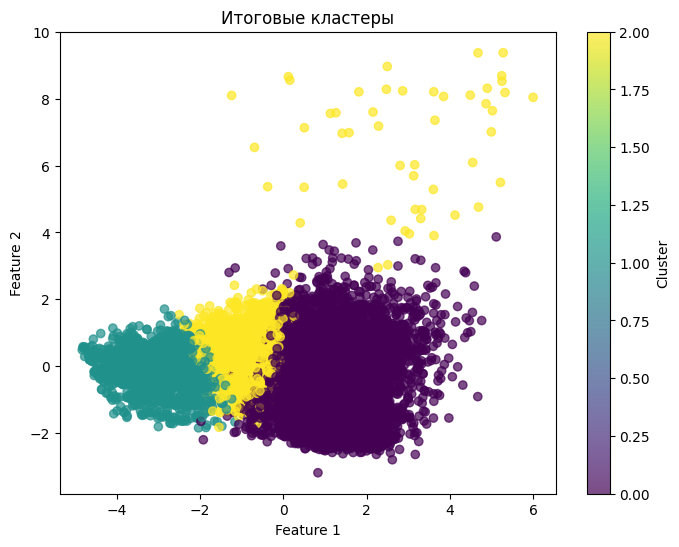

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df_reduced[:, 0], df_reduced[:, 1], c=labels, cmap='viridis', alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Итоговые кластеры')
plt.colorbar(label='Cluster')

plt.show()

Иерархическая кластеризация

График датасета используя t-SNE

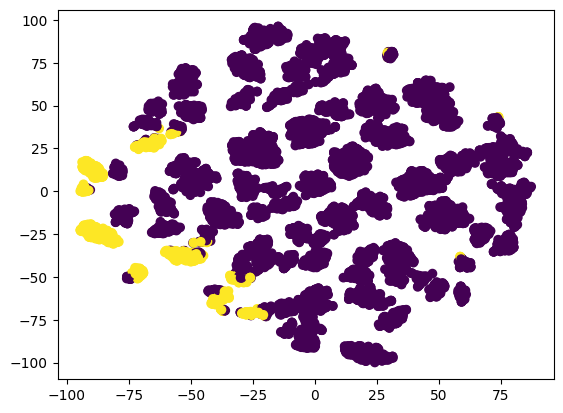

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_tsne = tsne.fit_transform(df)

scatter = plt.scatter(df_tsne[:, 0], df_tsne[:, 1], c=y, cmap='viridis')
plt.show()

Кластеризация через linkage и оценка методов cophenet (чем ближе к 1, тем лучше)

In [19]:
dists = pdist(df)

single

In [20]:
Z_single = linkage(df, method='single')
c_single, coph_dists_single = cophenet(Z_single, dists)

c_single

np.float64(0.6390391943535705)

complete

In [21]:
Z_complete = linkage(df, method='complete')
c_complete, coph_dists_complete = cophenet(Z_complete, dists)

c_complete

np.float64(0.5916240176064981)

ward

In [22]:
Z_ward = linkage(df, method='ward')
c_ward, coph_dists_ward = cophenet(Z_ward, dists)

c_ward

np.float64(0.41894531373620847)

Дендрограмма

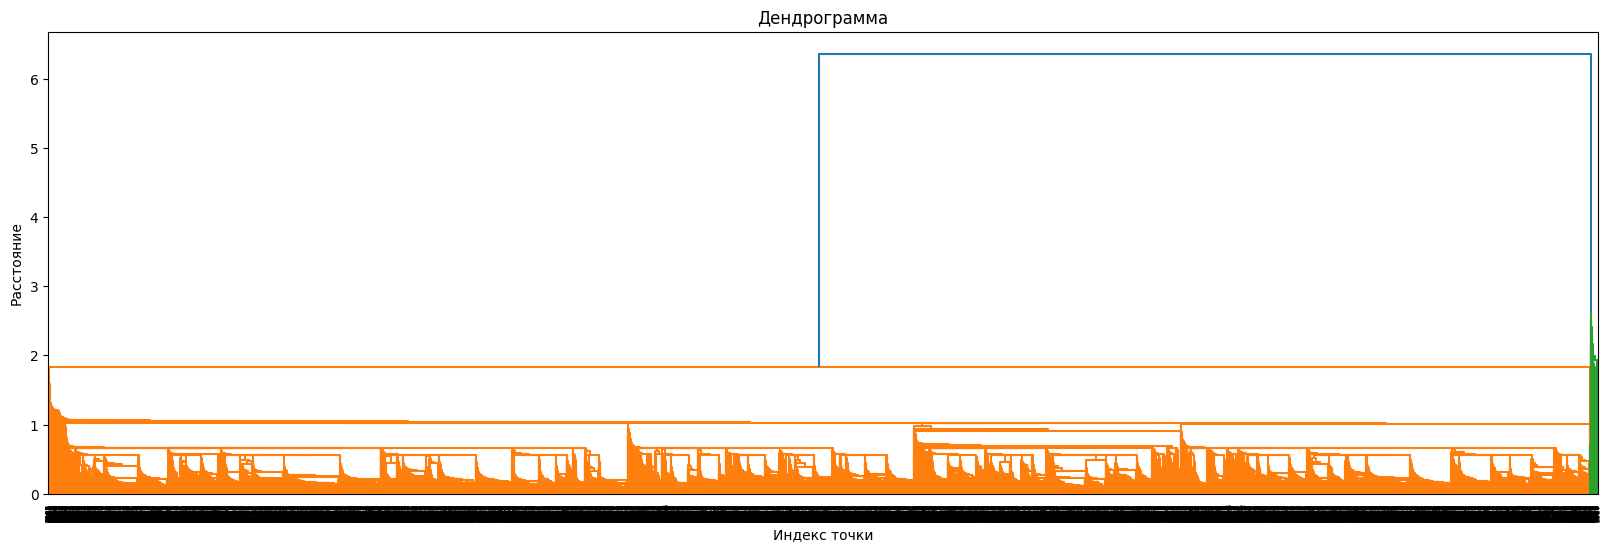

In [29]:
plt.figure(figsize=(20, 6))
dendrogram(Z_single)
plt.title('Дендрограмма')
plt.xlabel('Индекс точки')
plt.ylabel('Расстояние')
plt.show()